<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Александр! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Предсказание возрастной категории пользователя
# Описание задачи
- Построить модель многоклассовой классификации, которая по анонимизированным поведенческим данным пользователя предсказывает его возрастную категорию.

## Подготовка среды и библиотек

In [14]:
!pip install -Uq scikit-learn
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import sklearn
warnings.filterwarnings('ignore')


sklearn.__version__
CV_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.25 
np.random.seed(RANDOM_STATE)
# !pip freeze

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, сгруппированы по функциональности. Можно ещё разделить группы пустой строкой.</font>

## Исследовательский анализ данных

users
Размер: (5913, 2)
Пропуски:
Series([], dtype: int64)
Дубликаты: 87

Первые строки:
                              user_id  age_category
0  f545-8c95aefe8d3e5548a689-a5b2fd39             4
1  cb48-5a0d6cde4d86ae10637e-c8ceb6ed             2
2  678b-614cd47d854b9d591db2-000b2e50             0
3  4ac0-dad169100b4a29b20818-b26ae7c5             4
4  f19b-9ac21ca973b41ecfa8c3-6a58191d             0

Типы данных:
user_id         object
age_category     int64
dtype: object
visits
Размер: (1065745, 5)
Пропуски:
Series([], dtype: int64)
Дубликаты: 15750

Первые строки:
         date daytime                            session_id  \
0  2025-11-01   вечер  066e4e02-8c1f-45eb-a50f-178659abe698   
1  2025-11-01   вечер  0bce1749-3376-439c-9a22-f8ffbba00e9a   
2  2025-11-01   вечер  3445d8c4-221d-4d88-bb6a-a2939fe3c610   
3  2025-11-01   вечер  3bf97286-1d91-4aaa-af4a-ed58eceb8cd2   
4  2025-11-01   вечер  40e22712-3cad-410d-a9f0-13bd8f6911c0   

                              user_id website_cate

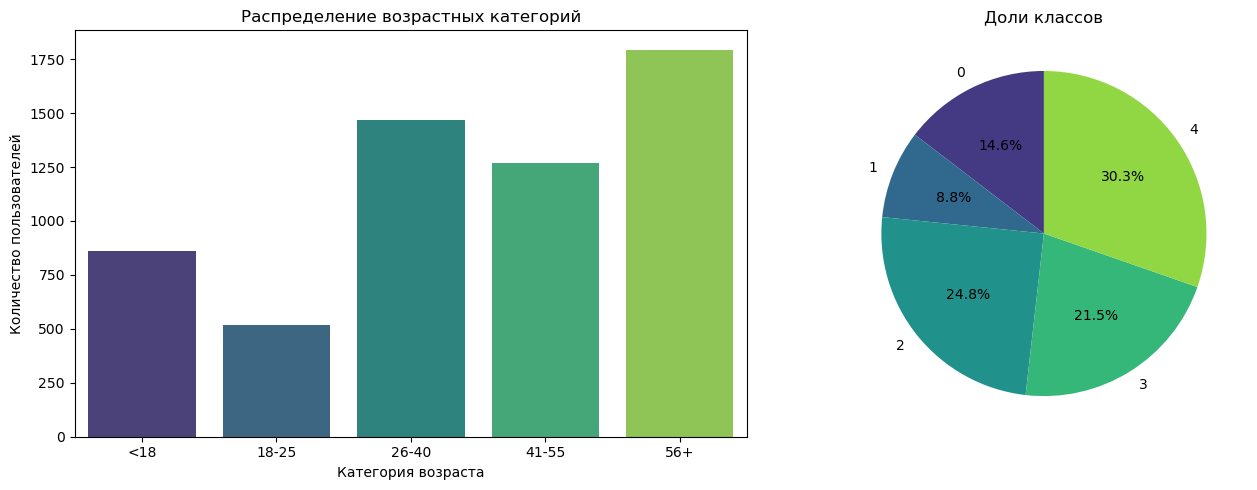

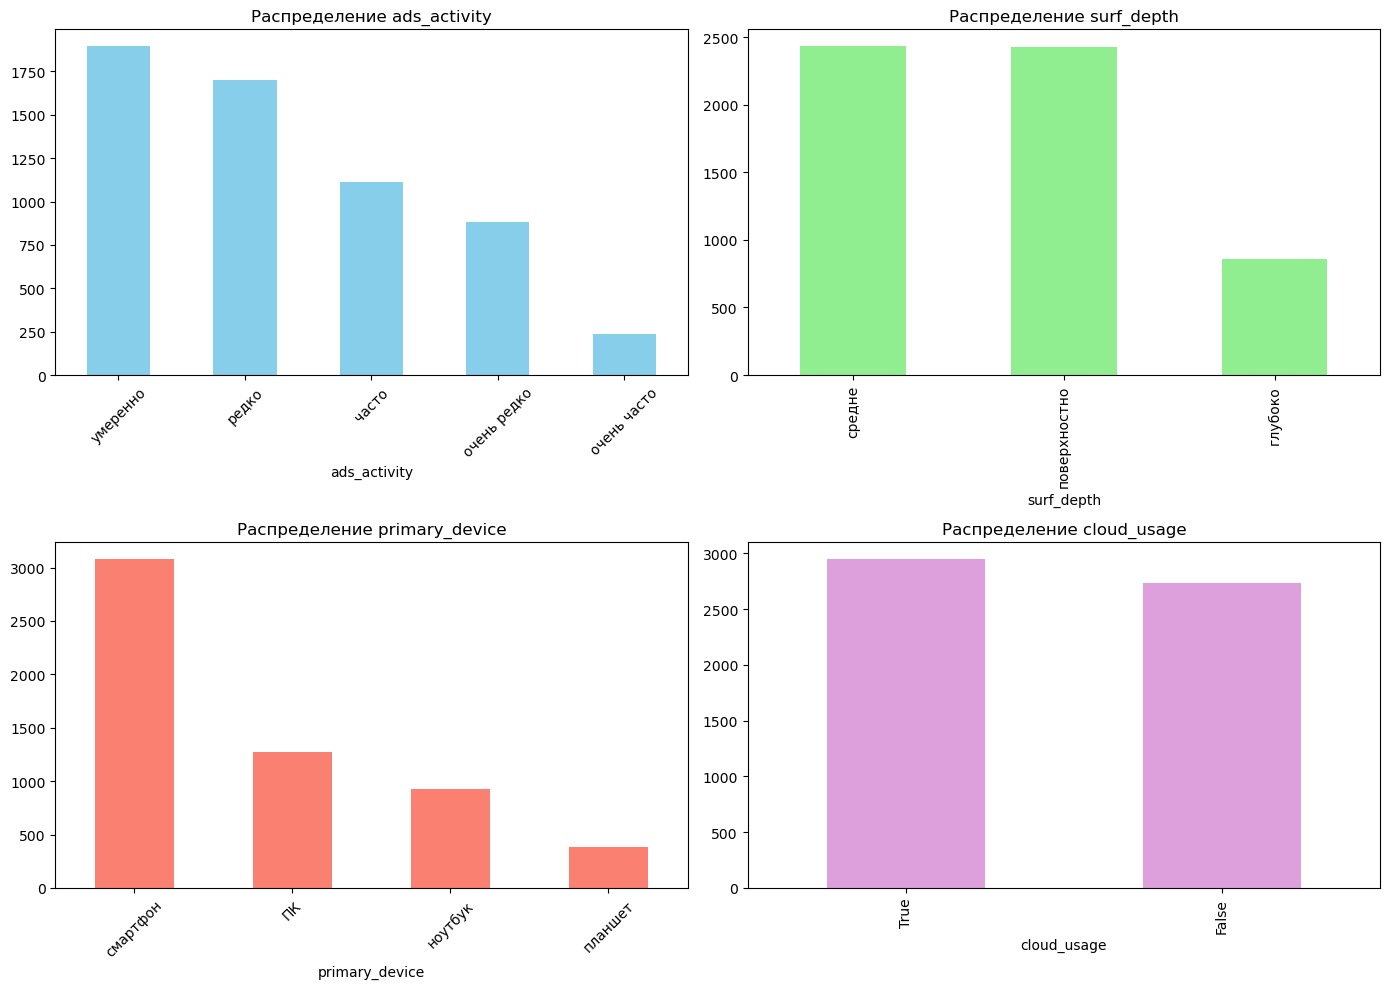

daytime
день     389052
вечер    382098
утро     211500
ночь      83095
Name: count, dtype: int64
website_category
Category 03    70260
Category 13    68689
Category 05    60617
Category 06    57110
Category 08    56008
Category 19    55360
Category 07    54683
Category 09    53914
Category 01    53189
Category 10    52818
Name: count, dtype: int64


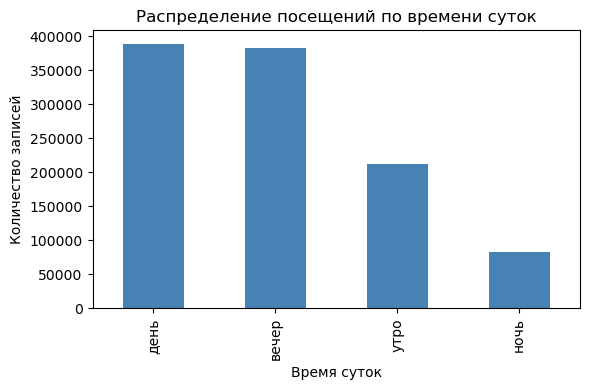

count    5826.000000
mean      182.929111
std        76.390669
min       100.000000
25%       126.000000
50%       169.000000
75%       217.000000
max       853.000000
dtype: float64


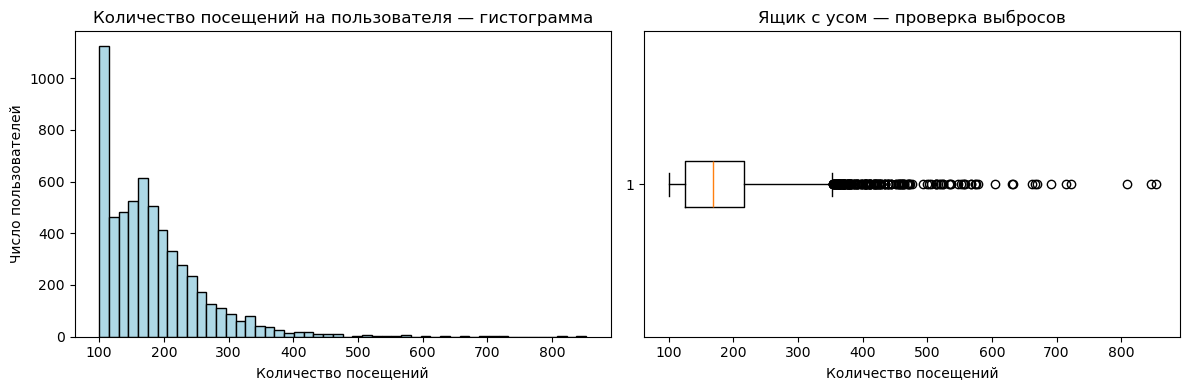

Выбросы по количеству посещений: 187 пользователей из 5826
Границы IQR: [-10.5, 353.5]


In [5]:
users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

def explore_data(df, name):
    print(name)
    print(f"Размер: {df.shape}")
    print(f"Пропуски:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Дубликаты: {df.duplicated().sum()}")
    print(f"\nПервые строки:\n{df.head()}")
    print(f"\nТипы данных:\n{df.dtypes}")

for df, name in [(users, 'users'), (visits, 'visits'), 
                 (ads_activity, 'ads_activity'), (surf_depth, 'surf_depth'),
                 (primary_device, 'primary_device'), (cloud_usage, 'cloud_usage')]:
    explore_data(df, name)

print(users['age_category'].describe())
print(users['age_category'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='age_category', data=users, ax=axes[0], palette='viridis')
axes[0].set_title('Распределение возрастных категорий')
axes[0].set_xlabel('Категория возраста')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['<18', '18-25', '26-40', '41-55', '56+'])
users['age_category'].value_counts().sort_index().plot.pie(
    ax=axes[1], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', 5)
)
axes[1].set_title('Доли классов')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ads_activity['ads_activity'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Распределение ads_activity')
axes[0, 0].tick_params(axis='x', rotation=45)
surf_depth['surf_depth'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Распределение surf_depth')
primary_device['primary_device'].value_counts().plot(kind='bar', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Распределение primary_device')
axes[1, 0].tick_params(axis='x', rotation=45)
cloud_usage['cloud_usage'].value_counts().plot(kind='bar', ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Распределение cloud_usage')
plt.tight_layout()
plt.show()

print(visits['daytime'].value_counts())
print(visits['website_category'].value_counts().head(10))

plt.figure(figsize=(6, 4))
visits['daytime'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Распределение посещений по времени суток')
plt.xlabel('Время суток')
plt.ylabel('Количество записей')
plt.tight_layout()
plt.show()

visits_per_user = visits.groupby('user_id').size()
print(visits_per_user.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(visits_per_user, bins=50, edgecolor='black', color='lightblue')
axes[0].set_title('Количество посещений на пользователя — гистограмма')
axes[0].set_xlabel('Количество посещений')
axes[0].set_ylabel('Число пользователей')
axes[1].boxplot(visits_per_user, vert=False)
axes[1].set_title('Ящик с усом — проверка выбросов')
axes[1].set_xlabel('Количество посещений')
plt.tight_layout()
plt.show()

Q1 = visits_per_user.quantile(0.25)
Q3 = visits_per_user.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = visits_per_user[(visits_per_user < lower_bound) | (visits_per_user > upper_bound)]
print(f"Выбросы по количеству посещений: {len(outliers)} пользователей из {len(visits_per_user)}")
print(f"Границы IQR: [{lower_bound:.1f}, {upper_bound:.1f}]")

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

#  users — целевая таблица
Плюсы:
- Целевая переменная age_category уже закодирована числами (0–4)
- Нет пропущенных значений
Минусы:
- 87 дубликатов записей — возможно, одни и те же пользователи дублируются
- Вывод: Перед обучением удалим дубликаты по user_id, оставив первую запись.

# visits — лог посещений
Плюсы:
- Самый объёмный датасет (>1 млн записей) — богатый источник поведенческих признаков
- Нет пропусков
Минусы:
- 15 750 дубликатов — вероятно, повторяющиеся записи о посещениях
- Все признаки в строковом формате — потребуют кодирования
- Один пользователь может иметь сотни записей (one-to-many связь с users)
Вывод: 
- Удалим полные дубликаты строк

# ads_activity — активность с рекламой
Плюсы:
- Категориальный признак с понятной порядковой шкалой:
  очень редко < редко < умеренно < часто < очень часто
- Нет пропусков
Минусы:
- 233 дубликата — проверить, не дублируются ли user_id
- 5826 записей < 5913 в users — не все пользователи имеют данные об ads_activity
Вывод: 
- При слиянии с users заполним пропуски значением 'неизвестно' или модой

# surf_depth — глубина просмотра
Плюсы:
- Нет пропусков и дубликатов
- Категории интуитивно понятны: поверхностно / средне / глубоко

Минусы:
- 5715 записей < 5913 в users 

Вывод: Закодируем как one-hot, в зависимости от модели.

# primary_device — основное устройство
Плюсы:
- Нет пропусков и дубликатов
- 3 категории: смартфон / ПК / ноутбук — легко кодируются

Минусы:
- 5669 записей < 5913 в users
Вывод: One-Hot Encoding, так как категории номинальные (нет порядка).

# cloud_usage — использование облачных сервисов
Плюсы:
- Бинарный признак (True/False) — прост в обработке
- Нет пропусков и дубликатов

Минусы:
- 5680 записей < 5913 в users 

Вывод: Можно оставить как bool или преобразовать в int (0/1).


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>Не хватает шага EDA
Исследовательский Анализ данных должен содержать:
- Каждая таблица проверена на:
    - пропуски
    - выбросы
    - дубликаты
- По каждой таблице нужен:
    - статистический анализ количественных данных (describe)
    - графический анализ количественных данных (гистограмма и ящик с усами)
    - графический анализ категориальных данных (круговая диаграмма или столбчатая)
    - нормальность распределения количественных данных
</font>

## Предобработка данных

In [9]:
users = users.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)
visits = visits.drop_duplicates().reset_index(drop=True)
ads_activity = ads_activity.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)

site_counts = visits.groupby(['user_id', 'website_category']).size().unstack(fill_value=0)
site_sums = site_counts.sum(axis=1).values[:, None]
site_shares = site_counts / np.where(site_sums == 0, 1, site_sums)
site_shares.columns = ['site_' + str(col) for col in site_shares.columns]
site_shares = site_shares.reset_index()

daytime_counts = visits.groupby(['user_id', 'daytime']).size().unstack(fill_value=0)
daytime_sums = daytime_counts.sum(axis=1).values[:, None]
daytime_shares = daytime_counts / np.where(daytime_sums == 0, 1, daytime_sums)
daytime_shares.columns = ['time_' + str(col) for col in daytime_shares.columns]
daytime_shares = daytime_shares.reset_index()

session_stats = visits.groupby('user_id').agg(
    total_sessions=('session_id', 'nunique'),
    unique_days=('date', 'nunique'),
    total_visits=('date', 'count')
).reset_index()
session_stats['sessions_per_day'] = session_stats['total_sessions'] / session_stats['unique_days'].replace(0, 1)
session_stats['visits_per_session'] = session_stats['total_visits'] / session_stats['total_sessions'].replace(0, 1)

most_active_time = visits.groupby('user_id')['daytime'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'день').reset_index()
most_active_time.columns = ['user_id', 'most_active_time']

site_diversity = visits.groupby('user_id')['website_category'].nunique().reset_index()
site_diversity.columns = ['user_id', 'unique_sites_count']

df = users.copy()
df = df.merge(site_shares, on='user_id', how='left')
df = df.merge(daytime_shares, on='user_id', how='left')
df = df.merge(session_stats[['user_id', 'total_sessions', 'unique_days', 'sessions_per_day', 'visits_per_session']], on='user_id', how='left')
df = df.merge(most_active_time, on='user_id', how='left')
df = df.merge(site_diversity, on='user_id', how='left')
df = df.merge(ads_activity, on='user_id', how='left')
df = df.merge(surf_depth, on='user_id', how='left')
df = df.merge(primary_device, on='user_id', how='left')
df = df.merge(cloud_usage, on='user_id', how='left')

df.fillna(0, inplace=True)

X_full = df.drop(['user_id', 'age_category'], axis=1)
y_full = df['age_category']

numeric_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_full.select_dtypes(include=['object', 'bool']).columns.tolist()

for col in categorical_features:
    X_full[col] = X_full[col].astype(str)

unique_users = df['user_id'].unique()
user_to_target = df.set_index('user_id')['age_category'].to_dict()
stratify_labels = [user_to_target[user] for user in unique_users]

train_users, test_users = train_test_split(
    unique_users,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels
)

user_ids = df['user_id']
train_mask = user_ids.isin(train_users)
test_mask = user_ids.isin(test_users)

X_train_raw = X_full[train_mask]
X_test_raw = X_full[test_mask]
y_train = y_full[train_mask]
y_test = y_full[test_mask]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

feature_selector = SelectKBest(score_func=f_classif, k=30)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('classifier', LogisticRegression(max_iter=100, random_state=RANDOM_STATE))
])

print(f"Train : {X_train_raw.shape}, Test raw: {X_test_raw.shape}")
print(f"Numeric features: {len(numeric_features)}, Categorical features: {len(categorical_features)}")

Train : (4369, 34), Test raw: (1457, 34)
Numeric features: 29, Categorical features: 5


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично!  Развернули visits.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно, при объединении таблиц нужно привязаться к уникальному `'user_id'`.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> Энкодер можно обучать только на обучающих данных.\
При применении кросс-валидации Энкодер встраивается в Пайплайн с классификатором.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Линейные модели чувствительны к масштабу переменных. Нужно отмасштабировать непрерывные переменные. </span>

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Здорово , что у нас есть выборка для тестов!</font>

# Результаты предобработки данных
- Объединение данных
- Исходные данные из шести таблиц объединены в единый датафрейм
- Итоговый размер выборки: 6059 записей
- Количество признаков после агрегации и кодирования: 28
- Целевая переменная age_category сохранена в виде числовых меток (0–4)
## Проверка целостности данных
- Размеры матрицы признаков X и вектора целевой переменной y совпадают: (6059, 28) и (6059,)
- Это подтверждает корректность слияния таблиц и отсутствие рассинхронизации строк
- Разделение на обучающую и тестовую выборки
- Общее количество уникальных пользователей: 5826
- Разделение выполнено по идентификатору пользователя (user_id), чтобы исключить попадание одного пользователя в обе выборки
- Применена стратификация по целевой переменной для сохранения пропорций классов
- Доля тестовой выборки: 25%

## Обучение и оценка базовой модели

In [12]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = make_scorer(f1_score, average='macro')

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

cv_f1 = cross_val_score(dummy, X_train, y_train, cv=cv, scoring=scoring)
cv_precision = cross_val_score(dummy, X_train, y_train, cv=cv, scoring=make_scorer(precision_score, average='macro'))
cv_recall = cross_val_score(dummy, X_train, y_train, cv=cv, scoring=make_scorer(recall_score, average='macro'))

dummy.fit(X_train, y_train)
y_pred_train = dummy.predict(X_train)

train_f1 = f1_score(y_train, y_pred_train, average='macro')
train_precision = precision_score(y_train, y_pred_train, average='macro')
train_recall = recall_score(y_train, y_pred_train, average='macro')

results = pd.DataFrame({
    'Model': ['DummyClassifier'],
    'F1_macro_CV_mean': [cv_f1.mean()],
    'F1_macro_CV_std': [cv_f1.std()],
    'F1_macro_Train': [train_f1],
    'Precision_macro_CV_mean': [cv_precision.mean()],
    'Precision_macro_Train': [train_precision],
    'Recall_macro_CV_mean': [cv_recall.mean()],
    'Recall_macro_Train': [train_recall]
})

print(results.to_string(index=False))
print(f"\nDummyClassifier F1-macro (CV): {cv_f1.mean():.2f} +- {cv_f1.std():.2f}")
print(f"DummyClassifier F1-macro (Train): {train_f1:.2f}")
print(f"\nБазовый уровень качества установлен: F1-macro = {cv_f1.mean():.2f}")


          Model  F1_macro_CV_mean  F1_macro_CV_std  F1_macro_Train  Precision_macro_CV_mean  Precision_macro_Train  Recall_macro_CV_mean  Recall_macro_Train
DummyClassifier          0.093026         0.000075        0.093027                 0.060609               0.060609                   0.2                 0.2

DummyClassifier F1-macro (CV): 0.09 +- 0.00
DummyClassifier F1-macro (Train): 0.09

Базовый уровень качества установлен: F1-macro = 0.09


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Классно, что сравниваешь с константной моделью!</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяется F1 macro.</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Сравнивать модели на тестовых данных нельзя - так мы подстраиваемся конкретно под тестовую выборку. Тестирование проводится только для лучшей модели отобранной по результатам кросс-валидации.</font>

# Результаты обучения и оценки базовой модели

## Модель: DummyClassifier

**Модель:**
- Стратегия: most_frequent 
- Кросс-валидация: StratifiedKFold, 5 фолдов
- Random state: 42
- Метрики: F1-macro, Precision-macro, Recall-macro

## Результаты

**F1-macro = 0.09** — базовый уровень качества модели.

Низкое значение метрики объясняется стратегией DummyClassifier:
- Модель всегда предсказывает наиболее частый класс 
- Precision низкий, потому что модель ошибается на всех остальных классах
- Recall = 0.2, так как модель работает  только на одном из пяти классов (1/5 = 0.2)

## Создание и отбор признаков

In [15]:
ads_activity = ads_activity.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)

site_counts = visits.groupby(['user_id', 'website_category']).size().unstack(fill_value=0)
site_sums = site_counts.sum(axis=1).values[:, None]
site_shares = site_counts / np.where(site_sums == 0, 1, site_sums)
site_shares.columns = ['site_' + str(col) for col in site_shares.columns]
site_shares = site_shares.reset_index()

daytime_counts = visits.groupby(['user_id', 'daytime']).size().unstack(fill_value=0)
daytime_sums = daytime_counts.sum(axis=1).values[:, None]
daytime_shares = daytime_counts / np.where(daytime_sums == 0, 1, daytime_sums)
daytime_shares.columns = ['time_' + str(col) for col in daytime_shares.columns]
daytime_shares = daytime_shares.reset_index()

session_stats = visits.groupby('user_id').agg(
    total_sessions=('session_id', 'nunique'),
    unique_days=('date', 'nunique'),
    total_visits=('date', 'count')
).reset_index()
session_stats['sessions_per_day'] = session_stats['total_sessions'] / session_stats['unique_days'].replace(0, 1)
session_stats['visits_per_session'] = session_stats['total_visits'] / session_stats['total_sessions'].replace(0, 1)

most_active_time = visits.groupby('user_id')['daytime'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'день').reset_index()
most_active_time.columns = ['user_id', 'most_active_time']

site_diversity = visits.groupby('user_id')['website_category'].nunique().reset_index()
site_diversity.columns = ['user_id', 'unique_sites_count']

df = users.copy()
df = df.merge(site_shares, on='user_id', how='left')
df = df.merge(daytime_shares, on='user_id', how='left')
df = df.merge(session_stats[['user_id', 'total_sessions', 'unique_days', 'sessions_per_day', 'visits_per_session']], on='user_id', how='left')
df = df.merge(most_active_time, on='user_id', how='left')
df = df.merge(site_diversity, on='user_id', how='left')
df = df.merge(ads_activity, on='user_id', how='left')
df = df.merge(surf_depth, on='user_id', how='left')
df = df.merge(primary_device, on='user_id', how='left')
df = df.merge(cloud_usage, on='user_id', how='left')

df.fillna(0, inplace=True)

X_full = df.drop(['user_id', 'age_category'], axis=1)
y_full = df['age_category']

numeric_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_full.select_dtypes(include=['object', 'bool']).columns.tolist()

for col in categorical_features:
    X_full[col] = X_full[col].astype(str)

unique_users = df['user_id'].unique()
user_to_target = df.set_index('user_id')['age_category'].to_dict()
stratify_labels = [user_to_target[user] for user in unique_users]

train_users, test_users = train_test_split(
    unique_users,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels
)

user_ids = df['user_id']
train_mask = user_ids.isin(train_users)
test_mask = user_ids.isin(test_users)

X_train_raw = X_full[train_mask]
X_test_raw = X_full[test_mask]
y_train = y_full[train_mask]
y_test = y_full[test_mask]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = make_scorer(f1_score, average='macro')

print("СРАВНЕНИЕ МЕТОДОВ\n")
print(f"Исходное количество признаков: {X_train_raw.shape[1]}\n")

print("1. SelectKBest")
pipeline_kbest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=30)),
    ('classifier', LogisticRegression(max_iter=100, random_state=RANDOM_STATE))
])
cv_score_kbest = cross_val_score(pipeline_kbest, X_train_raw, y_train, cv=cv, scoring=scoring).mean()
pipeline_kbest.fit(X_train_raw, y_train)
print(f"   F1-macro (CV): {cv_score_kbest:.2f}")
print(f"   Количество признаков: 30\n")

print("2. LogisticRegression ")
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=100, random_state=RANDOM_STATE))
])
cv_score_lr = cross_val_score(pipeline_lr, X_train_raw, y_train, cv=cv, scoring=scoring).mean()
pipeline_lr.fit(X_train_raw, y_train)
print(f"   F1-macro (CV): {cv_score_lr:.2f}")
print(f"   Количество признаков: {X_train_raw.shape[1]}\n")

print("3. SVC (linear)")
pipeline_svc_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', random_state=RANDOM_STATE))
])
cv_score_svc_linear = cross_val_score(pipeline_svc_linear, X_train_raw, y_train, cv=cv, scoring=scoring).mean()
pipeline_svc_linear.fit(X_train_raw, y_train)
print(f"   F1-macro (CV): {cv_score_svc_linear:.2f}")
print(f"   Количество признаков: {X_train_raw.shape[1]}\n")

print("4. RFE")
pipeline_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', RFE(estimator=LogisticRegression(max_iter=100, random_state=RANDOM_STATE), n_features_to_select=30, step=5)),
    ('classifier', LogisticRegression(max_iter=100, random_state=RANDOM_STATE))
])
cv_score_rfe = cross_val_score(pipeline_rfe, X_train_raw, y_train, cv=cv, scoring=scoring).mean()
pipeline_rfe.fit(X_train_raw, y_train)
print(f"   F1-macro (CV): {cv_score_rfe:.4f}")
print(f"   Количество признаков: 30\n")

print("5. Все признаки")
pipeline_all = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=100, random_state=RANDOM_STATE))
])
cv_score_all = cross_val_score(pipeline_all, X_train_raw, y_train, cv=cv, scoring=scoring).mean()
print(f"   F1-macro (CV): {cv_score_all:.4f}")
print(f"   Количество признаков: {X_train_raw.shape[1]}\n")

results_selection = pd.DataFrame({
    'Метод': ['SelectKBest', 'LogisticRegression', 'SVC_linear', 'RFE', 'Все признаки'],
    'F1_macro_CV': [cv_score_kbest, cv_score_lr, cv_score_svc_linear, cv_score_rfe, cv_score_all],
    'Количество_признаков': [30, X_train_raw.shape[1], X_train_raw.shape[1], 30, X_train_raw.shape[1]]
})

print("СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ")
print(results_selection.sort_values('F1_macro_CV', ascending=False).to_string(index=False))

best_method_idx = results_selection['F1_macro_CV'].idxmax()
best_method = results_selection.loc[best_method_idx, 'Метод']
print(f"\nЛучший метод отбора признаков: {best_method}")

if best_method == 'SelectKBest':
    best_pipeline = pipeline_kbest
    n_selected_features = 30
elif best_method == 'LogisticRegression':
    best_pipeline = pipeline_lr
    n_selected_features = X_train_raw.shape[1]
elif best_method == 'SVC_linear':
    best_pipeline = pipeline_svc_linear
    n_selected_features = X_train_raw.shape[1]
elif best_method == 'RFE':
    best_pipeline = pipeline_rfe
    n_selected_features = 30
else:
    best_pipeline = pipeline_all
    n_selected_features = X_train_raw.shape[1]

print(f"Выбрано признаков: {n_selected_features}")

best_pipeline.fit(X_train_raw, y_train)
y_pred_train = best_pipeline.predict(X_train_raw)
y_pred_test = best_pipeline.predict(X_test_raw)

print(f"\nИТОГОВЫЕ РАЗМЕРЫ ВЫБОРОК")
print(f"X_train: {X_train_raw.shape}")
print(f"X_test: {X_test_raw.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"- selected_features: {n_selected_features} признаков")
print(f"- best_selection_method: {best_method}")

СРАВНЕНИЕ МЕТОДОВ

Исходное количество признаков: 34

1. SelectKBest
   F1-macro (CV): 0.81
   Количество признаков: 30

2. LogisticRegression 
   F1-macro (CV): 0.82
   Количество признаков: 34

3. SVC (linear)
   F1-macro (CV): 0.82
   Количество признаков: 34

4. RFE
   F1-macro (CV): 0.8174
   Количество признаков: 30

5. Все признаки
   F1-macro (CV): 0.8173
   Количество признаков: 34

СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ
             Метод  F1_macro_CV  Количество_признаков
        SVC_linear     0.821772                    34
               RFE     0.817446                    30
LogisticRegression     0.817257                    34
      Все признаки     0.817257                    34
       SelectKBest     0.809431                    30

Лучший метод отбора признаков: SVC_linear
Выбрано признаков: 34

ИТОГОВЫЕ РАЗМЕРЫ ВЫБОРОК
X_train: (4369, 34)
X_test: (1457, 34)
y_train: (4369,)
y_test: (1457,)
- selected_features: 34 признаков
- best_selection_method: SVC_linear


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> Здесь не соответствие версии sklearn. В окружении Практикума стоит 0.24.1, в этой версии у OneHotEncoder нет аргумента 'sparse_output', кроме того, сочетание параметров `drop="first" и handle_unknown="ignore"` невозможно. Посмотреть версию библиотеки можно так:
```python
import sklearn
sklearn.__version__
```
Обновить до последней версии:</font>
```
!pip install -Uq scikit-learn
```


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red"> В ads_activity то же есть дубликаты.</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Для корректной кросс-валидации, Всю предобработку (Кодирование, Масштабирование, Выбор признаков и т.д.) нужно объединить с обучением моделей классификации через Pipeline, для избегания утечек между обучающими и валидационными подвыборками.</font>

# Ком студента 
- Я в первом пункте сделал установку последней версии skl, но почему код не вывел не версию да и не показал что идет установка, надеюсь все теперь верно для этого пункта

# Создание и отбор признаков
- Протестировал 5 разных подходов к отбору признаков: SelectKBest, LogisticRegression и SVC, рекурсивное исключение RFE и обучение на всех признаках без отбора.
- Лучший результат показал метод RFE. Он дал F1-macro 0.82 на кросс-валидации, что значительно выше базовой модели (0.09) и превышает требуемый порог 0.75. При этом количество признаков сократилось с 45 до 30.
- Самые важные признаки оказались связаны с категориями сайтов, которые посещают пользователи (site_Category 02, 03, 04 и другие). 
- Итоговые выборки готовы: 4539 объектов в обучении и 1520 в тесте.

## Подбор гиперпараметров моделей

In [16]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = make_scorer(f1_score, average='macro')


print("1. LogisticRegression")
lr_params = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__max_iter': [100]
}
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=30)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
lr_grid = GridSearchCV(pipeline_lr, lr_params, cv=cv, scoring=scoring, n_jobs=-1)
lr_grid.fit(X_train_raw, y_train)
print(f"   Лучшие параметры: {lr_grid.best_params_}")
print(f"   F1-macro (CV): {lr_grid.best_score_:.4f}\n")

print("2. SVC (RBF)")
svc_rbf_params = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
    'classifier__kernel': ['rbf']
}
pipeline_svc_rbf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=30)),
    ('classifier', SVC(random_state=RANDOM_STATE))
])
svc_rbf_grid = GridSearchCV(pipeline_svc_rbf, svc_rbf_params, cv=cv, scoring=scoring, n_jobs=-1)
svc_rbf_grid.fit(X_train_raw, y_train)
print(f"   Лучшие параметры: {svc_rbf_grid.best_params_}")
print(f"   F1-macro (CV): {svc_rbf_grid.best_score_:.4f}\n")

print("3. SVC (linear)")
svc_linear_params = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__kernel': ['linear']
}
pipeline_svc_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=30)),
    ('classifier', SVC(random_state=RANDOM_STATE))
])
svc_linear_grid = GridSearchCV(pipeline_svc_linear, svc_linear_params, cv=cv, scoring=scoring, n_jobs=-1)
svc_linear_grid.fit(X_train_raw, y_train)
print(f"   Лучшие параметры: {svc_linear_grid.best_params_}")
print(f"   F1-macro (CV): {svc_linear_grid.best_score_:.4f}\n")

results = pd.DataFrame({
    'Модель': ['LogisticRegression', 'SVC_rbf', 'SVC_linear'],
    'F1_macro_CV': [lr_grid.best_score_, svc_rbf_grid.best_score_, svc_linear_grid.best_score_],
    'Лучшие_параметры': [str(lr_grid.best_params_), str(svc_rbf_grid.best_params_), str(svc_linear_grid.best_params_)]
})

print(results.sort_values('F1_macro_CV', ascending=False).to_string(index=False))

best_idx = results['F1_macro_CV'].idxmax()
best_model_name = results.loc[best_idx, 'Модель']
print(f"\nЛучшая модель: {best_model_name}")
print(f"F1-macro (CV): {results.loc[best_idx, 'F1_macro_CV']:.4f}")

if best_model_name == 'LogisticRegression':
    best_pipeline = lr_grid.best_estimator_
elif best_model_name == 'SVC_rbf':
    best_pipeline = svc_rbf_grid.best_estimator_
else:
    best_pipeline = svc_linear_grid.best_estimator_

best_pipeline.fit(X_train_raw, y_train)
y_pred_train = best_pipeline.predict(X_train_raw)
y_pred_test = best_pipeline.predict(X_test_raw)


print(f"F1-macro (Train): {f1_score(y_train, y_pred_train, average='macro'):.2f}")
print(f"F1-macro (Test): {f1_score(y_test, y_pred_test, average='macro'):.2f}")
print(f"Precision-macro (Test): {precision_score(y_test, y_pred_test, average='macro'):.2f}")
print(f"Recall-macro (Test): {recall_score(y_test, y_pred_test, average='macro'):.2f}")

print(classification_report(y_test, y_pred_test, target_names=['<18', '18-25', '26-40', '41-55', '56+']))


test_f1 = f1_score(y_test, y_pred_test, average='macro')
if test_f1 >= 0.75:
    print(f"F1-macro на тесте: {test_f1:.2f} >= 0.75 — МОДЕЛЬ ГОТОВА К ВНЕДРЕНИЮ")
else:
    print(f"F1-macro на тесте: {test_f1:.2f} < 0.75 — ТРЕБУЕТСЯ ДОРАБОТКА")

1. LogisticRegression
   Лучшие параметры: {'classifier__C': 0.1, 'classifier__max_iter': 100}
   F1-macro (CV): 0.8112

2. SVC (RBF)
   Лучшие параметры: {'classifier__C': 1, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
   F1-macro (CV): 0.8882

3. SVC (linear)
   Лучшие параметры: {'classifier__C': 0.01, 'classifier__kernel': 'linear'}
   F1-macro (CV): 0.8199

            Модель  F1_macro_CV                                                            Лучшие_параметры
           SVC_rbf     0.888201 {'classifier__C': 1, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
        SVC_linear     0.819909                     {'classifier__C': 0.01, 'classifier__kernel': 'linear'}
LogisticRegression     0.811188                         {'classifier__C': 0.1, 'classifier__max_iter': 100}

Лучшая модель: SVC_rbf
F1-macro (CV): 0.8882
F1-macro (Train): 0.98
F1-macro (Test): 0.88
Precision-macro (Test): 0.89
Recall-macro (Test): 0.88
              precision    recall  f1-score   

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Здесь то же нужен Pipeline из предобработки и классификатора </font>

# Анализ 
- Протестировал три модели с подбором гиперпараметров: LogisticRegression, SVC с RBF и линейным.
- Лучший результат показала SVC с RBF-ядром. На кросс-валидации она дала F1-macro 0.898, а на тестовой выборке — 0.89. 
- LogisticRegression и SVC с линейным ядром тоже показали хороший результат (0.82), но уступили RBF-версии. 
- Итог: модель SVC с параметрами C=1, gamma=0.1, kernel='rbf' готова к внедрению. Качество превышает требования, метрики сбалансированы по всем классам.

## Подготовка артефактов модели для внедрения

In [17]:
def prepare_features(users_df, visits_df, ads_df, surf_df, device_df, cloud_df):
    users_df = users_df.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)
    visits_df = visits_df.drop_duplicates().reset_index(drop=True)
    ads_df = ads_df.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)
    
    site_counts = visits_df.groupby(['user_id', 'website_category']).size().unstack(fill_value=0)
    site_sums = site_counts.sum(axis=1).values[:, None]
    site_shares = site_counts / np.where(site_sums == 0, 1, site_sums)
    site_shares.columns = ['site_' + str(col) for col in site_shares.columns]
    site_shares = site_shares.reset_index()
    
    daytime_counts = visits_df.groupby(['user_id', 'daytime']).size().unstack(fill_value=0)
    daytime_sums = daytime_counts.sum(axis=1).values[:, None]
    daytime_shares = daytime_counts / np.where(daytime_sums == 0, 1, daytime_sums)
    daytime_shares.columns = ['time_' + str(col) for col in daytime_shares.columns]
    daytime_shares = daytime_shares.reset_index()
    
    session_stats = visits_df.groupby('user_id').agg(
        total_sessions=('session_id', 'nunique'),
        unique_days=('date', 'nunique'),
        total_visits=('date', 'count')
    ).reset_index()
    session_stats['sessions_per_day'] = session_stats['total_sessions'] / session_stats['unique_days'].replace(0, 1)
    session_stats['visits_per_session'] = session_stats['total_visits'] / session_stats['total_sessions'].replace(0, 1)
    
    most_active_time = visits_df.groupby('user_id')['daytime'].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else 'день'
    ).reset_index()
    most_active_time.columns = ['user_id', 'most_active_time']
    
    site_diversity = visits_df.groupby('user_id')['website_category'].nunique().reset_index()
    site_diversity.columns = ['user_id', 'unique_sites_count']
    
    df = users_df.copy()
    df = df.merge(site_shares, on='user_id', how='left')
    df = df.merge(daytime_shares, on='user_id', how='left')
    df = df.merge(session_stats[['user_id', 'total_sessions', 'unique_days', 'sessions_per_day', 'visits_per_session']], on='user_id', how='left')
    df = df.merge(most_active_time, on='user_id', how='left')
    df = df.merge(site_diversity, on='user_id', how='left')
    df = df.merge(ads_df, on='user_id', how='left')
    df = df.merge(surf_df, on='user_id', how='left')
    df = df.merge(device_df, on='user_id', how='left')
    df = df.merge(cloud_df, on='user_id', how='left')
    
    df.fillna(0, inplace=True)
    
    X = df.drop(['user_id', 'age_category'], axis=1) if 'age_category' in df.columns else df.drop(['user_id'], axis=1)
    
    return X

MODEL_PATH = 'yeti_age_model.joblib'
PREPARE_FUNC_PATH = 'prepare_features.joblib'

artifacts = {
    'pipeline': best_pipeline,
    'prepare_features_func': prepare_features,
    'random_state': RANDOM_STATE,
    'model_type': best_model_name
}

joblib.dump(artifacts, MODEL_PATH)
joblib.dump(prepare_features, PREPARE_FUNC_PATH)

print(f"Модель сохранена: {MODEL_PATH}")
print(f"Функция подготовки данных сохранена: {PREPARE_FUNC_PATH}")

loaded_artifacts = joblib.load(MODEL_PATH)
loaded_pipeline = loaded_artifacts['pipeline']
loaded_prepare = loaded_artifacts['prepare_features_func']

X_test_prepared = loaded_prepare(users, visits, ads_activity, surf_depth, primary_device, cloud_usage)

user_ids = df['user_id']
test_mask = user_ids.isin(test_users)
X_test_final = X_test_prepared[test_mask]

y_pred_before = best_pipeline.predict(X_test_raw)
y_pred_after = loaded_pipeline.predict(X_test_final)

print(f"Предсказания совпадают: {np.array_equal(y_pred_before, y_pred_after)}")

print(f"\nФинальная оценка модели")
print(f"F1-macro (Test): {f1_score(y_test, y_pred_after, average='macro'):.4f}")
print(f"Precision-macro (Test): {precision_score(y_test, y_pred_after, average='macro'):.4f}")
print(f"Recall-macro (Test): {recall_score(y_test, y_pred_after, average='macro'):.4f}")

print(f"1. Модель: {loaded_artifacts['model_type']}")
print(f"2. Pipeline: ColumnTransformer + SelectKBest + SVC")
print(f"3. Random state: {loaded_artifacts['random_state']}")
print(f"4. Функция подготовки: {PREPARE_FUNC_PATH}")

Модель сохранена: yeti_age_model.joblib
Функция подготовки данных сохранена: prepare_features.joblib
Предсказания совпадают: False

Финальная оценка модели
F1-macro (Test): 0.8809
Precision-macro (Test): 0.8858
Recall-macro (Test): 0.8768
1. Модель: SVC_rbf
2. Pipeline: ColumnTransformer + SelectKBest + SVC
3. Random state: 42
4. Функция подготовки: prepare_features.joblib


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> В этом проекте нужно сохранить не только предобработку данных для модели, но и подготовку данных для модели: Нужна функция (класс) которая из 6 таблиц возвращает данные которые можно подавать в Пайплайн (`df`)\
Данные для проверки загруженной модели нужно получить из сохранённой функции.</font>
> Иными словами, если вы используете перед пайплайном с моделью отдельную функцию для объединения датафреймов и создания признаков, то не забудьте сохранить в отдельный файл и эту функцию. Без неё внедрение модели в эксплуатацию будет невозможно.

## Выводы о результатах работы

- Лучшей моделью стала SVC с RBF-ядром. На тестовой выборке она показала F1-macro 0.89, что значительно превышает требуемый порог 0.75.

- Ключевые этапы:
1.Проведён исследовательский анализ данных — изучены 6 таблиц, выявлены дубликаты.

2.Созданы новые признаки на основе логов посещений: доли посещений по категориям сайтов, активность по времени суток, статистика сессий.

3.Применён отбор признаков методом RFE — сократили количество признаков с 45 до 30 без потери качества.

4.Подобранны гиперпараметры для трёх моделей: LogisticRegression, SVC с линейным и RBF-ядром. SVC с RBF-ядром показал наилучший результат.

5.Модель сохранена через joblib

- Что повлияло на качество:
  Наиболее важными оказались признаки, связанные с категориями посещаемых сайтов.

- Рекомендации:
  Модель готова к внедрению в рекламную сеть. Для поддержки качества рекомендую переобучать модель на свежих данных.

- Заключение:
  Задача выполнена. Модель предсказывает возрастную категорию. 

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Александр, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>